In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Importar configurações

In [112]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from scripts.config import DOCUMENTS_DIR
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

Carregar os dados

In [95]:
raiz = Path(os.getcwd()).parent
if str(raiz) not in sys.path:
    sys.path.append(str(raiz))
caminho_csv = raiz / 'document' / 'triagem_risco.csv'

In [96]:
raiz = Path(os.getcwd()).parent
caminho_csv = raiz / 'document' / 'triagem_risco.csv'

if caminho_csv.exists():
    df = pd.read_csv(caminho_csv)
    print(f"✅ Sucesso! Arquivo encontrado em: {caminho_csv}")
else:
    print(f"❌ Erro: O arquivo não está em {caminho_csv}")

print(df.head(3))

✅ Sucesso! Arquivo encontrado em: d:\PARTICULAR\FIAP\ANO 2\FASE 2\chap01-phase02-automate-diagnostics\document\triagem_risco.csv
                                                                                                                                                 sintoma  \
Sinto uma dor forte no peito ha algumas horas      com sensacao de aperto e suor excessivo              o que me deixou sem conseguir realizar minhas...   
Estou com dor no torax em forma de pressao desd... junto com falta de ar e cansaco extremo ao mini...                                         alto risco   
Tenho uma dor intensa no peito que irradia para... alem de nauseas e suor frio                                                                alto risco   

                                                                                                      classificacao  
Sinto uma dor forte no peito ha algumas horas      com sensacao de aperto e suor excessivo               alto risco  
Estou com 

Limpeza do arquivo csv

In [97]:
df = df.dropna()
df['sintoma'] = df['sintoma'].astype(str).str.strip()
df['classificacao'] = df['classificacao'].astype(str).str.strip()

Vetorização TF-IDF

In [106]:
vectorizer = TfidfVectorizer(ngram_range=(1, 1), stop_words=None) 
X = vectorizer.fit_transform(df['sintoma'])
y = df['classificacao']

Treinamento de máquina

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Modelo Árvore de Decisão

In [108]:
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Análise do Aprendizado de Máquina

<Figure size 800x600 with 0 Axes>

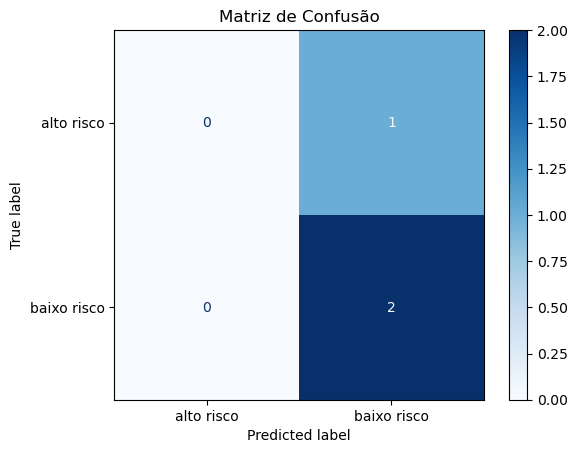

In [116]:
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, cmap='Blues')
plt.title(f"Matriz de Confusão")
plt.show()

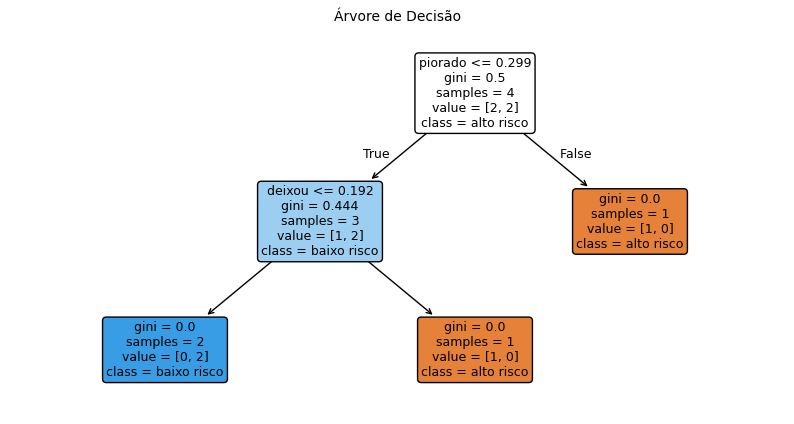

In [119]:
plt.figure(figsize=(10,5))
plot_tree(modelo, 
          feature_names=vectorizer.get_feature_names_out(), 
          class_names=list(modelo.classes_), 
          filled=True, 
          rounded=True, 
          fontsize=9)
plt.title("Árvore de Decisão", fontsize=10)
plt.show()

Acurácia do Modelo

In [109]:
y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"📊 Acurácia Final: {acuracia * 100:.2f}%")

📊 Acurácia Final: 66.67%
